In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler #USED FOR STANDARDISIING VALUES
from statsmodels.stats.outliers_influence import variance_inflation_factor # COLINEARITY CHECK
import plotly.express as a   #3D VISUALISATION GLOBE
import seaborn as sns  # CORELATION HEAT MAP
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # BAR CHART LEGEND
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [137]:
wdi = pd.read_csv("World development Indicators Data.csv")
column_names_climate = [
    'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N',
    'DJF', 'MAM', 'JJA', 'SON'
]
climate = pd.read_csv("Nasa_climate_data.csv",skiprows=2,sep=',',header=None,names=column_names_climate)
rli = pd.read_csv("red-list-index.csv")
print("WDI shape:", wdi.shape)
print("Climate shape:", climate.shape)
print("RLI shape:", rli.shape)

WDI shape: (95, 29)
Climate shape: (147, 19)
RLI shape: (8320, 4)


In [138]:
year_cols = [col for col in wdi.columns if "[" in col]
new_year_cols = {col: col.split(" ")[0] for col in year_cols}
wdi = wdi.rename(columns=new_year_cols)#  un clear year column name into normal year
print(wdi.columns[:10])

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000',
       '2001', '2002', '2003', '2004', '2005'],
      dtype='object')


In [139]:
wdi = wdi.rename(columns={
    "Country Name": "country",
    "Country Code": "country_code",
    "Series Name": "indicator",
    "Series Code": "indicator_code"
})
print(wdi.columns[:10])

Index(['country', 'country_code', 'indicator', 'indicator_code', '2000',
       '2001', '2002', '2003', '2004', '2005'],
      dtype='object')


In [140]:
wdi_long = wdi.melt(
    id_vars=["country", "country_code", "indicator", "indicator_code"],
    var_name="year",
    value_name="value"
)
print("Long shape:", wdi_long.shape)
wdi_long.head() # melt used for wide format

Long shape: (2375, 6)


,country,country_code,indicator,indicator_code,year,value
0,Brazil,BRA,Agricultural land (% of land area),AG.LND.AGRI.ZS,2000,27.3175012622426
1,Brazil,BRA,Energy use (kg of oil equivalent per capita),EG.USE.PCAP.KG.OE,2000,1081.36193393467
2,Brazil,BRA,Forest area (% of land area),AG.LND.FRST.ZS,2000,65.9343586013156
3,Brazil,BRA,Methane (CH4) emissions from Power Industry (E...,EN.GHG.CH4.PI.MT.CE.AR5,2000,0.0708
4,Brazil,BRA,Nitrous oxide (N2O) emissions from Power Indus...,EN.GHG.N2O.PI.MT.CE.AR5,2000,0.1762


In [141]:
wdi_long = wdi_long[wdi_long["country"].notna()]                                           #handling nan values
wdi_long = wdi_long[~wdi_long["country"].str.contains("Data from", na=False)]              #Not op used like focus on country column and removing meta date update
wdi_long = wdi_long[~wdi_long["country"].str.contains("Last Updated", na=False)]
print("After cleaning:", wdi_long.shape)

After cleaning: (2250, 6)


In [142]:
wdi_long["year"] = wdi_long["year"].astype(int)
wdi_long["value"] = wdi_long["value"].replace("..", np.nan)
wdi_long["value"] = pd.to_numeric(wdi_long["value"], errors="coerce")
print("Value dtype:", wdi_long["value"].dtype)
print("Total missing:", wdi_long["value"].isna().sum())

Value dtype: float64
Total missing: 774


In [143]:
wdi_long = wdi_long.sort_values(["country","indicator","year"])
wdi_long = wdi_long.dropna(subset=["value"])
print("After removing missing:", wdi_long.shape)
wdi_long = wdi_long[~wdi_long["indicator"].str.contains("species|threatened", case=False, na=False)]

After removing missing: (1476, 6)


In [144]:
missing_ratio = wdi_long.groupby("indicator")["value"].apply(lambda series: series.isna().mean())
drop_indicators = missing_ratio[missing_ratio > 0.6].index
wdi_long = wdi_long[~wdi_long["indicator"].isin(drop_indicators)]
print("Remaining indicators:", wdi_long["indicator"].nunique())

Remaining indicators: 11


In [145]:
print("Total missing after cleaning:", wdi_long["value"].isna().sum())

Total missing after cleaning: 0


In [146]:
panel = wdi_long.pivot_table(
    index=["country", "year"],
    columns="indicator",
    values="value"
).reset_index()
panel.columns.name = None
panel = panel.loc[:, ~panel.columns.str.contains("species|threatened", case=False)]
print(panel.shape)
panel.head()

(150, 13)


,country,year,Agricultural land (% of land area),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy use (kg of oil equivalent per capita),Forest area (% of land area),Fossil fuel energy consumption (% of total),Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",Renewable energy consumption (% of total final energy consumption),Terrestrial and marine protected areas (% of total territorial area),Terrestrial protected areas (% of total land area)
0,Brazil,2000,27.317501,2.007879,1081.361934,65.934359,58.004565,0.0708,0.1762,15.572382,42.7,NaN,NaN
1,Brazil,2001,27.329908,1.992821,1086.992993,65.461671,58.664719,0.0827,0.1874,15.552813,41.3,NaN,NaN
2,Brazil,2002,27.342315,1.968796,1103.401279,64.988983,56.805126,0.0906,0.1628,15.517601,42.9,NaN,NaN
3,Brazil,2003,27.354722,1.918394,1107.973916,64.516295,54.327692,0.1022,0.1767,15.470772,45.1,NaN,NaN
4,Brazil,2004,27.367130,1.999783,1157.169056,64.043608,54.350383,0.1126,0.1917,15.416351,45.2,NaN,NaN


In [147]:
climate_clean = climate[["Year", "DJF", "MAM", "JJA", "SON"]].copy()
climate_clean["Year"] = pd.to_numeric(climate_clean["Year"], errors="coerce")
climate_clean = climate_clean.dropna(subset=["Year"])
climate_clean["Year"] = climate_clean["Year"].astype(int)
climate_clean.columns = ["year", "temp_winter", "temp_spring", "temp_summer", "temp_autumn"]
panel = panel.merge(climate_clean, on="year", how="left") # added nasa data as a column
print(panel.head())

  country  year  Agricultural land (% of land area)  \
0  Brazil  2000                           27.317501   
1  Brazil  2001                           27.329908   
2  Brazil  2002                           27.342315   
3  Brazil  2003                           27.354722   
4  Brazil  2004                           27.367130   

   Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  \
0                                           2.007879                            
1                                           1.992821                            
2                                           1.968796                            
3                                           1.918394                            
4                                           1.999783                            

   Energy use (kg of oil equivalent per capita)  Forest area (% of land area)  \
0                                   1081.361934                     65.934359   
1                   

In [148]:
numeric_cols = panel.select_dtypes(include=["float64", "int64"]).columns
numeric_cols = [col for col in numeric_cols if col not in ["year"]]
desc_stats = panel[numeric_cols].describe().T
desc_stats["skewness"] = panel[numeric_cols].skew()
desc_stats["kurtosis"] = panel[numeric_cols].kurtosis() #shows characteristics of the dataset
desc_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Agricultural land (% of land area),144.0,51.565701,13.560020,27.317501,46.066858,52.172532,60.430464,73.732071,-0.343678,-0.582793
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),150.0,7.359693,5.411091,0.939790,2.271966,7.295216,9.767403,21.011875,0.801928,-0.143354
Energy use (kg of oil equivalent per capita),144.0,2962.101739,2199.324380,393.380886,1257.194558,2431.969118,3897.263616,8055.145489,0.898407,-0.212253
Forest area (% of land area),144.0,30.974907,15.494155,12.210143,21.729351,28.538322,33.786986,65.934359,0.998868,0.060486
Fossil fuel energy consumption (% of total),144.0,51.324200,38.013283,0.000000,0.000000,70.498533,84.141320,91.424732,-0.501813,-1.584743
Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),150.0,0.838625,0.848019,0.070800,0.262075,0.422800,1.458325,4.135000,1.716859,3.006040
Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),150.0,10.856747,14.258451,0.162800,0.671075,4.196800,15.960575,64.794300,1.890766,3.505914
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",126.0,27.254663,21.397328,7.176021,12.126209,15.387358,49.578701,79.037396,0.932966,-0.722150
Renewable energy consumption (% of total final energy consumption),132.0,20.714394,16.132870,0.800000,7.700000,13.600000,36.125000,50.000000,0.561963,-1.298864
Terrestrial and marine protected areas (% of total territorial area),72.0,22.186111,12.279335,3.400000,14.700000,20.400000,29.425000,42.100000,0.048099,-1.144636


In [149]:
pressure_cols = [
    "Forest area (% of land area)",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)",
    "Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e)",
    "PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",
    "Terrestrial and marine protected areas (% of total territorial area)",
    "temp_winter",
    "temp_spring",
    "temp_summer",
    "temp_autumn"
]


In [150]:
pressure_cols = [col for col in panel.columns if col not in ["country", "year"]]
X_pressure = panel[pressure_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pressure)
# VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_pressure.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]
vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

,feature,VIF
0,Energy use (kg of oil equivalent per capita),1144.375450
1,Carbon dioxide (CO2) emissions excluding LULUC...,1102.628676
2,Forest area (% of land area),701.231598
3,Agricultural land (% of land area),623.892924
4,Nitrous oxide (N2O) emissions from Power Indus...,325.036056
5,Methane (CH4) emissions from Power Industry (E...,241.289018
6,Terrestrial protected areas (% of total land a...,72.631519
7,Renewable energy consumption (% of total final...,71.690402
8,"PM2.5 air pollution, mean annual exposure (mic...",61.988774
9,temp_spring,13.632028


In [151]:
rli = rli.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Red List Index": "rli" #  column name renamed
})
rli = rli[["country", "year", "rli"]]
rli["year"] = pd.to_numeric(rli["year"], errors="coerce")
rli["rli"] = pd.to_numeric(rli["rli"], errors="coerce")
rli = rli.dropna()
print(rli.head())
print("RLI shape:", rli.shape)

       country  year   rli
0  Afghanistan  1993  0.93
1  Afghanistan  1994  0.93
2  Afghanistan  1995  0.93
3  Afghanistan  1996  0.93
4  Afghanistan  1997  0.93
RLI shape: (8320, 3)


In [152]:
panel_full = panel.merge(rli, on=["country", "year"], how="inner")
print("Merged dataset shape:", panel_full.shape)
panel_full.head()

Merged dataset shape: (150, 18)


,country,year,Agricultural land (% of land area),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy use (kg of oil equivalent per capita),Forest area (% of land area),Fossil fuel energy consumption (% of total),Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",Renewable energy consumption (% of total final energy consumption),Terrestrial and marine protected areas (% of total territorial area),Terrestrial protected areas (% of total land area),temp_winter,temp_spring,temp_summer,temp_autumn,rli
0,Brazil,2000,27.317501,2.007879,1081.361934,65.934359,58.004565,0.0708,0.1762,15.572382,42.7,NaN,NaN,.40,.49,.40,.32,0.9
1,Brazil,2001,27.329908,1.992821,1086.992993,65.461671,58.664719,0.0827,0.1874,15.552813,41.3,NaN,NaN,.39,.54,.53,.58,0.9
2,Brazil,2002,27.342315,1.968796,1103.401279,64.988983,56.805126,0.0906,0.1628,15.517601,42.9,NaN,NaN,.70,.70,.56,.59,0.9
3,Brazil,2003,27.354722,1.918394,1107.973916,64.516295,54.327692,0.1022,0.1767,15.470772,45.1,NaN,NaN,.59,.59,.57,.62,0.9
4,Brazil,2004,27.367130,1.999783,1157.169056,64.043608,54.350383,0.1126,0.1917,15.416351,45.2,NaN,NaN,.68,.54,.39,.61,0.9


In [153]:
panel_full.isna().sum()

,0
country,0
year,0
Agricultural land (% of land area),6
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),0
Energy use (kg of oil equivalent per capita),6
Forest area (% of land area),6
Fossil fuel energy consumption (% of total),6
Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),0
Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),0
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",24


In [154]:
panel_full = panel_full.drop(columns=[
"Terrestrial and marine protected areas (% of total territorial area)",
"Terrestrial protected areas (% of total land area)"
])

In [155]:
panel_full = panel_full.dropna()

In [156]:
panel_full.isna().sum()

,0
country,0
year,0
Agricultural land (% of land area),0
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),0
Energy use (kg of oil equivalent per capita),0
Forest area (% of land area),0
Fossil fuel energy consumption (% of total),0
Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),0
Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),0
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",0


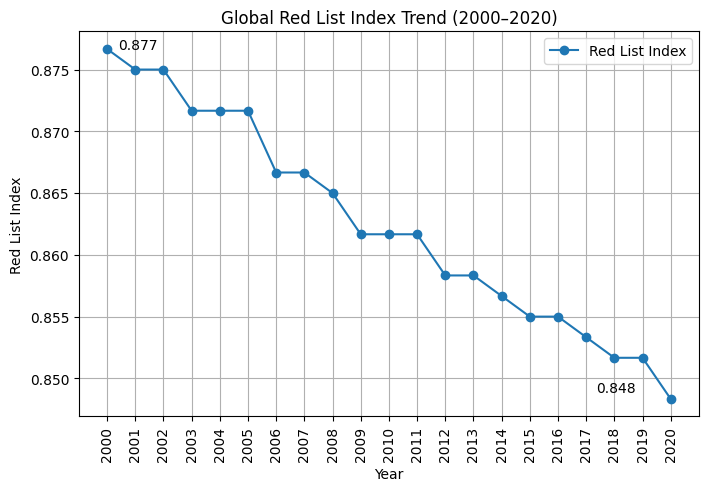

In [157]:
rli_trend = panel_full.groupby("year")["rli"].mean()
plt.figure(figsize=(8,5))
plt.plot(rli_trend.index, rli_trend.values, marker='o', label="Red List Index")
plt.xticks(list(rli_trend.index), rotation=90)
plt.annotate(f"{rli_trend.iloc[0]:.3f}",
             (rli_trend.index[0], rli_trend.iloc[0]),
             textcoords="offset points",
             xytext=(8,0),
             ha='left')
plt.annotate(f"{rli_trend.iloc[-1]:.3f}",
             (rli_trend.index[-1], rli_trend.iloc[-1]),
             textcoords="offset points",
             xytext=(-25,5),
             ha='right')
plt.title("Global Red List Index Trend (2000–2020)")
plt.xlabel("Year")
plt.ylabel("Red List Index")
plt.legend()
plt.grid(True)
plt.show()

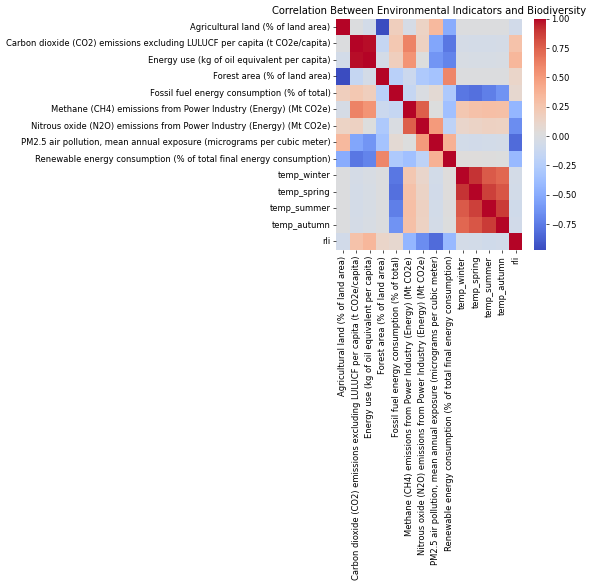

In [158]:
plt.figure(figsize=(5,5),dpi=60)
corr = panel_full.drop(columns=["country","year"]).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Between Environmental Indicators and Biodiversity")
plt.show()

In [159]:
panel_full["country"].unique()[:20]

array(['Brazil', 'China', 'Germany', 'India', 'United Kingdom',
       'United States'], dtype=object)

In [160]:
selected_countries = ["Brazil", "China", "Germany", "India", "United Kingdom", "United States"]
panel_filtered = panel_full[panel_full["country"].isin(selected_countries)]
print(panel_filtered.shape)

(126, 16)


In [161]:
panel_filtered = panel_filtered[(panel_filtered["year"] >= 2000) & (panel_filtered["year"] <= 2020)]
print(panel_filtered.shape)

(126, 16)


In [162]:
panel_filtered = panel_filtered.dropna()
print(panel_filtered.shape)
drop_cols = [
    "Energy use (kg of oil equivalent per capita)",
    "Agricultural land (% of land area)",
    "Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e)"
]
panel_filtered = panel_filtered.drop(columns=drop_cols, errors='ignore')
print("After dropping high VIF columns:", panel_filtered.shape)

(126, 16)
After dropping high VIF columns: (126, 13)


In [163]:
feature_cols = [col for col in panel_filtered.columns if col not in ["country", "year", "rli"]]
X_vif = panel_filtered[feature_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)
# calculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = feature_cols
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
print(vif_data)

                                             feature       VIF
0                                        temp_spring  9.610321
1  Renewable energy consumption (% of total final...  9.603699
2  Carbon dioxide (CO2) emissions excluding LULUC...  8.707956
3                                        temp_summer  7.229077
4                                        temp_winter  6.046282
5  PM2.5 air pollution, mean annual exposure (mic...  5.518665
6                       Forest area (% of land area)  5.517880
7                                        temp_autumn  4.720837
8        Fossil fuel energy consumption (% of total)  4.345783
9  Methane (CH4) emissions from Power Industry (E...  4.294922


In [164]:
panel_filtered[["country", "year", "rli"]].head()
panel_filtered[["country", "year", "rli"]].tail()

,country,year,rli
141,United States,2016,0.84
142,United States,2017,0.84
143,United States,2018,0.84
144,United States,2019,0.84
145,United States,2020,0.83


In [165]:
Latestdata = panel_filtered[panel_filtered["year"] == 2020]
RLIglobe = a.choropleth(
    Latestdata,
    locations="country",
    locationmode="country names",
    color="rli",
    hover_name="country",
    projection="orthographic",
    color_continuous_scale="Viridis"
)
RLIglobe.update_layout(
    title=dict(
        text="RLI Across Six Countries in 2020",
        x=0.5,
        xanchor='center',
        font=dict(size=16)
    ),
    geo=dict(
        showcoastlines=True,
        showland=True,
        landcolor="lightgray",
        projection_rotation=dict(
            lon=20,
            lat=10
        )
    ),
    margin=dict(
        l=0,
        r=0,
        t=40,
        b=0
    ),
    coloraxis_colorbar=dict(
        title="RLI",
        x=0.85,
        len=0.75
    )
)
RLIglobe.show()

In [166]:
X = panel_filtered.drop(columns=["country", "year", "rli"])
y = panel_filtered["rli"]
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (75, 10)
Validation: (25, 10)
Test: (26, 10)


In [167]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Linear Regression R2: 0.959322059792304
Linear Regression RMSE: 0.020740666217437705


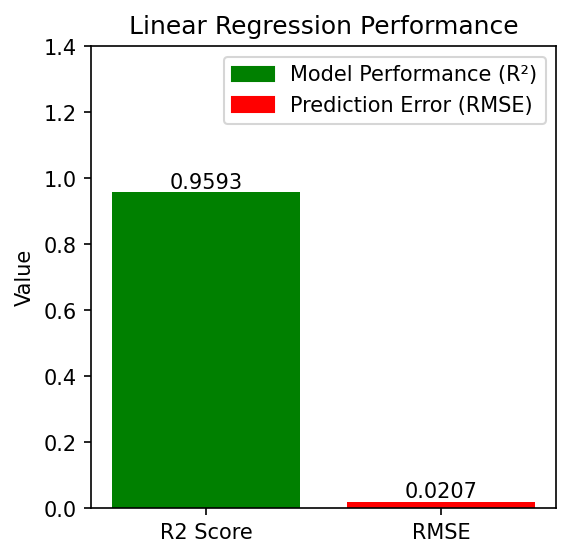

In [168]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
test_pred_lr = lr.predict(X_test_scaled)
lr_r2 = r2_score(y_test, test_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, test_pred_lr))
print("Linear Regression R2:", lr_r2)
print("Linear Regression RMSE:", lr_rmse)
plt.figure(figsize=(4,4),dpi=150)
metrics = ["R2 Score", "RMSE"]
values = [lr_r2, lr_rmse]
colors = ['green', 'red']
plt.bar(metrics, values, color=colors)
for i, v in enumerate(values):
    plt.text(i, v + 0.01, str(round(v,4)), ha='center')
plt.title("Linear Regression Performance", fontsize=12)
plt.ylabel("Value")
plt.grid(False)
plt.ylim(0, 1.4)
green_patch = mpatches.Patch(color='green', label='Model Performance (R²)')
red_patch = mpatches.Patch(color='red', label='Prediction Error (RMSE)')
plt.legend(handles=[green_patch, red_patch], loc='upper right')
plt.show()

Linear Regression R2: 0.959322059792304
Linear Regression RMSE: 0.020740666217437705


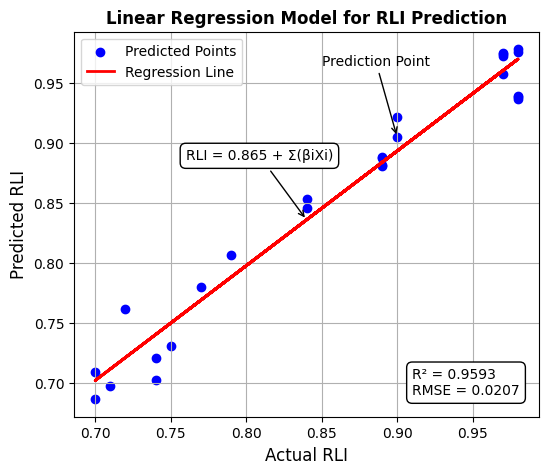

In [169]:
print("Linear Regression R2:", lr_r2)
print("Linear Regression RMSE:", lr_rmse)
plt.figure(figsize=(6,5),dpi=100)
plt.scatter(y_test, test_pred_lr, color='blue', label="Predicted Points")
m, b = np.polyfit(y_test, test_pred_lr, 1)
plt.plot(y_test, m*y_test + b, color='red', linewidth=2, label="Regression Line")
plt.xlabel("Actual RLI", fontsize=12)
plt.ylabel("Predicted RLI", fontsize=12)
plt.title("Linear Regression Model for RLI Prediction",
          fontsize=12, fontweight='bold')
plt.text(0.91, 0.69,
         f"R² = {round(lr_r2,4)}\nRMSE = {round(lr_rmse,4)}",
         fontsize=10,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4'))
plt.annotate(
    f"RLI = {round(lr.intercept_,3)} + Σ(βiXi)",
    xy=(y_test.iloc[8], m*y_test.iloc[8] + b),
    xytext=(y_test.iloc[8]-0.08, m*y_test.iloc[8] + b + 0.05),
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
)
idx = 10
plt.annotate(
    "Prediction Point",
    xy=(y_test.iloc[idx], test_pred_lr[idx]),   # exact point
    xytext=(y_test.iloc[idx] - 0.05, test_pred_lr[idx] + 0.06),  # ← LEFT + UP (angle)
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=10
)
plt.legend()
plt.grid(True)
plt.show()

In [170]:
# Intercept (β₀ value)
print("Intercept (beta_0):", lr.intercept_)
# Coefficients (beta values)
print("Coefficients (beta values):", lr.coef_)

Intercept (beta_0): 0.8645333333333334
Coefficients (beta values): [-1.47820746e-02  1.88392056e-02 -1.19765588e-02 -5.79831075e-02
 -5.06031311e-02 -6.19142626e-02 -2.62241858e-03 -7.24020286e-04
 -1.76712987e-03  2.95092919e-05]


In [171]:
print("Linear Regression RMSE:", lr_rmse)
lr_test_r2 = lr_r2
lr_test_rmse = lr_rmse

Linear Regression RMSE: 0.020740666217437705


Random Forest Validation R2: 0.9969993101545256
Random Forest Validation RMSE: 0.005711698521455629
Random Forest Test R2: 0.9991333159532821
Random Forest Test RMSE: 0.0028269139193994653


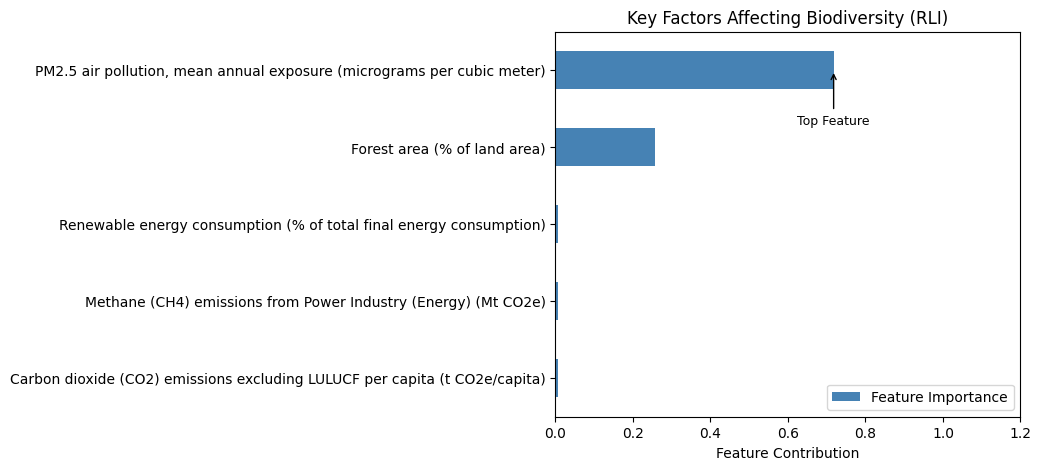

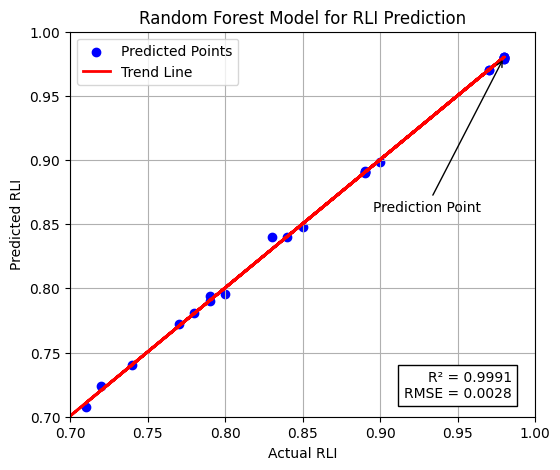

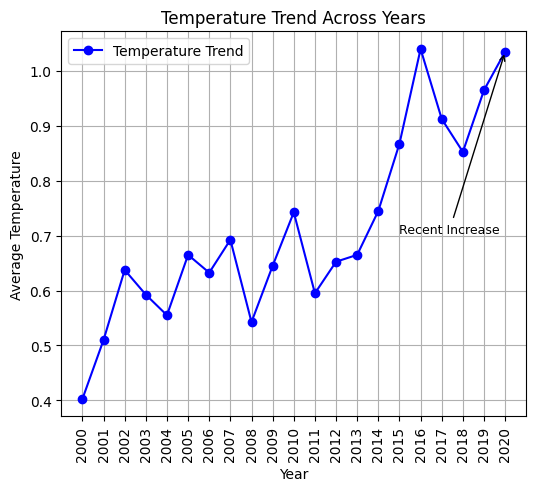

In [185]:
temp_cols = ["temp_winter", "temp_spring", "temp_summer", "temp_autumn"]
for col in temp_cols:
    panel_filtered[col] = pd.to_numeric(panel_filtered[col], errors="coerce")
panel_filtered = panel_filtered.dropna(subset=temp_cols)
panel_filtered["temp_combined"] = (
    panel_filtered["temp_winter"] +
    panel_filtered["temp_spring"] +
    panel_filtered["temp_summer"] +
    panel_filtered["temp_autumn"]
) / 4
X = panel_filtered.drop(columns=["country", "year", "rli"])
y = panel_filtered["rli"]
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=34)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=34)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
val_pred_rf = rf.predict(X_val_scaled)
rf_r2 = r2_score(y_val, val_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_val, val_pred_rf))
print("Random Forest Validation R2:", rf_r2)
print("Random Forest Validation RMSE:", rf_rmse)
test_pred_rf = rf.predict(X_test_scaled)
rf_test_r2 = r2_score(y_test, test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_rf))
print("Random Forest Test R2:", rf_test_r2)
print("Random Forest Test RMSE:", rf_test_rmse)
# 1. Feature Importance
plt.figure(figsize=(6,5))
importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(5)
top_features_sorted = top_features.sort_values()
top_features_sorted.plot(kind="barh", color='steelblue')
plt.title("Key Factors Affecting Biodiversity (RLI)")
plt.xlabel("Feature Contribution")
plt.xlim(0, 1.2)
max_feature = top_features_sorted.idxmax()
max_value = top_features_sorted.max()
y_pos = list(top_features_sorted.index).index(max_feature)
plt.annotate("Top Feature",
             xy=(max_value, y_pos),
             xytext=(max_value, y_pos - 0.7),  # above → arrow goes downward
             arrowprops=dict(arrowstyle='->'),
             fontsize=9,
             ha='center')
plt.legend(["Feature Importance"], loc='lower right')
plt.grid(False)
plt.show()
# 2. Actual versus Predicted
plt.figure(figsize=(6,5),dpi=100)
plt.scatter(y_test, test_pred_rf, color='blue', label='Predicted Points')
m, b = np.polyfit(y_test, test_pred_rf, 1)
plt.plot(y_test, m*y_test + b, color='red', linewidth=2, label='Trend Line')
plt.xlabel("Actual RLI")
plt.ylabel("Predicted RLI")
plt.title("Random Forest Model for RLI Prediction")
plt.text(0.95, 0.05,
         f"R² = {round(rf_test_r2,4)}\nRMSE = {round(rf_test_rmse,4)}",
         transform=plt.gca().transAxes,
         ha='right',
         bbox=dict(facecolor='white', edgecolor='black'))
idx = 2
plt.annotate("Prediction Point",
             xy=(y_test.iloc[idx], test_pred_rf[idx]),
             xytext=(y_test.iloc[idx]-0.05, test_pred_rf[idx]-0.12),
             arrowprops=dict(arrowstyle='->'),
             ha='center')
plt.xlim(0.7, 1.0)
plt.ylim(0.7, 1.0)
plt.legend()
plt.grid(True)
plt.show()
# 3. Temperature Trend
plt.figure(figsize=(6,5),dpi=100)
temp_trend = panel_filtered.groupby("year")["temp_combined"].mean().reset_index()
temp_trend = temp_trend.sort_values("year")
plt.plot(temp_trend["year"], temp_trend["temp_combined"],
         marker='o', color='blue', label='Temperature Trend')
plt.title("Temperature Trend Across Years")
plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.xticks(temp_trend["year"].astype(int), rotation=90)
plt.annotate("Recent Increase",
             xy=(temp_trend["year"].iloc[-1], temp_trend["temp_combined"].iloc[-1]),
             xytext=(temp_trend["year"].iloc[-6], temp_trend["temp_combined"].iloc[-1]-0.33),
             arrowprops=dict(arrowstyle='->'),
             fontsize=9)
plt.legend()
plt.grid(True)
plt.show()



In [173]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 10, 15]
}
rf_base = RandomForestRegressor(random_state=42)
grid = GridSearchCV(rf_base, param_grid, cv=3, scoring='r2')
grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'n_estimators': 150}
Best Cross Validation Score: 0.9934172966234911


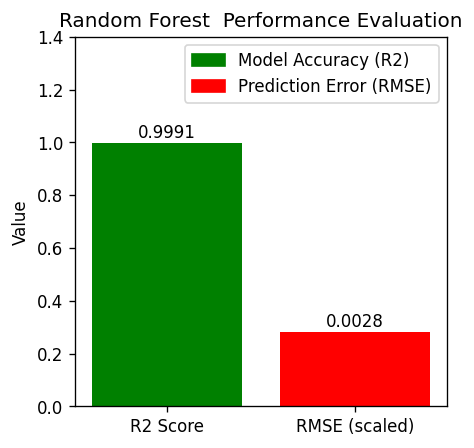

In [174]:
plt.figure(figsize=(4,4),dpi=120)
metrics = ["R2 Score", "RMSE (scaled)"]
values = [rf_test_r2, rf_test_rmse * 100]   # scaled RMSE because i got small rmse value so invisible in graph so for highlighting that.
colors = ['green', 'red']
plt.bar(metrics, values, color=colors)
plt.text(0, rf_test_r2 + 0.02, str(round(rf_test_r2,4)), ha='center')
plt.text(1, rf_test_rmse*100 + 0.02, str(round(rf_test_rmse,4)), ha='center')
plt.ylim(0, 1.4)
plt.title("Random Forest  Performance Evaluation")
plt.ylabel("Value")
green_patch = mpatches.Patch(color='green', label='Model Accuracy (R2)')
red_patch = mpatches.Patch(color='red', label='Prediction Error (RMSE)')
plt.legend(handles=[green_patch, red_patch], loc='upper right')
plt.grid(False)
plt.show()

Gradient Boost Validation R2: 0.9976110506074365
Gradient Boost Validation RMSE: 0.0050963376846467
Gradient Boost Test R2: 0.9985898509544583
Gradient Boost Test RMSE: 0.003605908413861516
Cross Validation R2 Scores: [0.99155869 0.9974692  0.99902661 0.9983409  0.99914745]
Mean CV R2: 0.9971085702964231


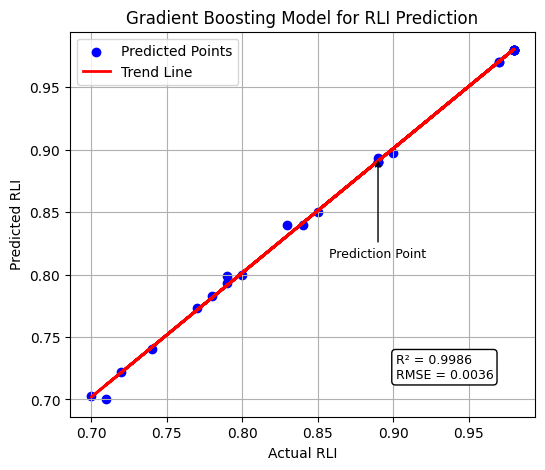

In [175]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# GRADIENT BOOSTING
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=34
)
gb.fit(X_train_scaled, y_train)
val_pred_gb = gb.predict(X_val_scaled) #validation
gb_r2 = r2_score(y_val, val_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_val, val_pred_gb))
print("Gradient Boost Validation R2:", gb_r2)
print("Gradient Boost Validation RMSE:", gb_rmse)
test_pred_gb = gb.predict(X_test_scaled)  #testing
gb_test_r2 = r2_score(y_test, test_pred_gb)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_gb))
print("Gradient Boost Test R2:", gb_test_r2)
print("Gradient Boost Test RMSE:", gb_test_rmse)
cv_scores = cross_val_score(gb, X_train_scaled, y_train, cv=5, scoring='r2')
print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
plt.figure(figsize=(6,5))
plt.scatter(y_test, test_pred_gb, color='blue', label='Predicted Points')
m, b = np.polyfit(y_test, test_pred_gb, 1)
plt.plot(y_test, m*y_test + b, color='red', linewidth=2, label='Trend Line')
plt.title("Gradient Boosting Model for RLI Prediction")
plt.xlabel("Actual RLI")
plt.ylabel("Predicted RLI")
plt.text(0.70, 0.10,
         f"R² = {round(gb_test_r2,4)}\nRMSE = {round(gb_test_rmse,4)}",
         transform=plt.gca().transAxes,
         fontsize=9,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))
idx = -1
plt.annotate("Prediction Point",
             xy=(y_test.iloc[idx], test_pred_gb[idx]),
             xytext=(y_test.iloc[idx], test_pred_gb[idx]-0.08),
             arrowprops=dict(arrowstyle='->'),
             fontsize=9,
             ha='center')
plt.legend()
plt.grid(True)
plt.show()

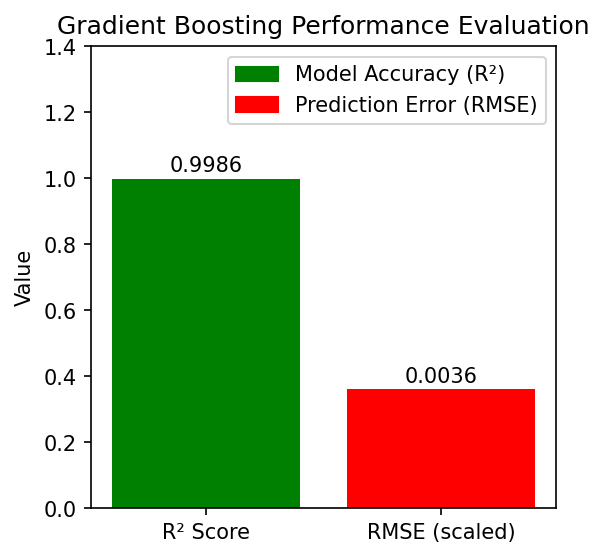

In [176]:
plt.figure(figsize=(4,4),dpi=150)
metrics = ["R² Score", "RMSE (scaled)"]
values = [gb_test_r2, gb_test_rmse * 100]
plt.bar(metrics, values, color=['green', 'red'])
plt.text(0, gb_test_r2 + 0.02, str(round(gb_test_r2,4)), ha='center')
plt.text(1, gb_test_rmse*100 + 0.02, str(round(gb_test_rmse,4)), ha='center')
plt.ylim(0, 1.4)
plt.title("Gradient Boosting Performance Evaluation")
plt.ylabel("Value")
plt.legend(handles=[
    mpatches.Patch(color='green', label='Model Accuracy (R²)'),
    mpatches.Patch(color='red', label='Prediction Error (RMSE)')
], loc='upper right')

plt.grid(False)
plt.show()

Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Optimized Model R2 = 0.9976686346790276
Optimized Model RMSE = 0.004636468879081886


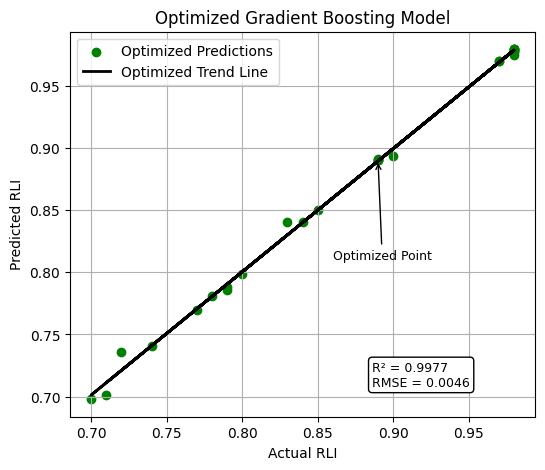

In [177]:
# OPTIMIZATION OF GRADIENT BOOSTING MODEL
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}
grid = GridSearchCV(
    GradientBoostingRegressor(random_state=40),
    param_grid,
    cv=3,
    scoring='r2'
)
grid.fit(X_train_scaled, y_train)
print("Best Parameters Found:", grid.best_params_)
best_gb = grid.best_estimator_
y_pred_best = best_gb.predict(X_test_scaled)
print("Optimized Model R2 =", r2_score(y_test, y_pred_best))
print("Optimized Model RMSE =", np.sqrt(mean_squared_error(y_test, y_pred_best)))
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_best, color='green', label='Optimized Predictions')
m, b = np.polyfit(y_test, y_pred_best, 1)
plt.plot(y_test, m*y_test + b, color='black', linewidth=2, label='Optimized Trend Line')
plt.title("Optimized Gradient Boosting Model")
plt.xlabel("Actual RLI")
plt.ylabel("Predicted RLI")
plt.text(0.65, 0.08,
         f"R² = {round(r2_score(y_test, y_pred_best),4)}\nRMSE = {round(np.sqrt(mean_squared_error(y_test, y_pred_best)),4)}",
         transform=plt.gca().transAxes,
         fontsize=9,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))
idx = -1
plt.annotate("Optimized Point",
             xy=(y_test.iloc[idx], y_pred_best[idx]),
             xytext=(y_test.iloc[idx]-0.03, y_pred_best[idx]-0.08),
             arrowprops=dict(arrowstyle='->'),
             fontsize=9)

plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [178]:
from sklearn.neural_network import MLPRegressor
ann = MLPRegressor(
    hidden_layer_sizes=(32,),
    activation='relu',
    solver='adam',
    max_iter=500,
    alpha=0.01,                # regularization
    learning_rate_init=0.001,
    random_state=42
)
ann.fit(X_train_scaled, y_train)
# VALIDATION
val_pred_ann = ann.predict(X_val_scaled)
ann_r2 = r2_score(y_val, val_pred_ann)
ann_rmse = np.sqrt(mean_squared_error(y_val, val_pred_ann))
print("ANN Validation R2:", ann_r2)
print("ANN Validation RMSE:", ann_rmse)
test_pred_ann = ann.predict(X_test_scaled)
ann_test_r2 = r2_score(y_test, test_pred_ann)
ann_test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_ann))
print("ANN Test R2:", ann_test_r2)
print("ANN Test RMSE:", ann_test_rmse)

ANN Validation R2: -0.3094399468949436
ANN Validation RMSE: 0.11931567836056511
ANN Test R2: -2.974111082010802
ANN Test RMSE: 0.19142655518543483


Best ANN parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.01}
Best validation R2: -0.5942210147169996
Optimized ANN R2 score: -0.11298221235530836
Optimized ANN RMSE: 0.10130393023542399


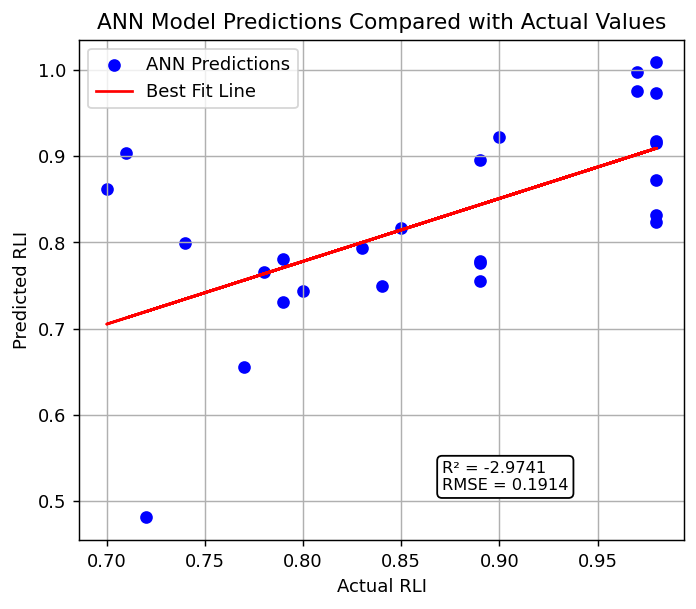

In [179]:
#Different ANN configurations to Improve Performance
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
ann_param_grid = {
    'hidden_layer_sizes': [(16,), (32,), (64,)],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.01]
}
ann_grid = GridSearchCV(
    MLPRegressor(max_iter=500, random_state=40),
    ann_param_grid,
    cv=3,
    scoring='r2'
)
ann_grid.fit(X_train_scaled, y_train)
print("Best ANN parameters:", ann_grid.best_params_)
print("Best validation R2:", ann_grid.best_score_)
# Optimized ANN model
best_ann = ann_grid.best_estimator_
y_pred_ann_opt = best_ann.predict(X_test_scaled)
print("Optimized ANN R2 score:", r2_score(y_test, y_pred_ann_opt))
print("Optimized ANN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ann_opt)))
plt.figure(figsize=(6,5),dpi=130)
plt.scatter(y_test, y_pred_ann_opt, color='blue', label="ANN Predictions")
m, b = np.polyfit(y_test, y_pred_ann_opt, 1)
plt.plot(y_test, m*y_test + b, color='red', label="Best Fit Line")
plt.xlabel("Actual RLI")
plt.ylabel("Predicted RLI")
plt.title("ANN Model Predictions Compared with Actual Values")
plt.legend()
plt.grid(True)
plt.text(0.60, 0.10,
         f"R² = {round(ann_test_r2,4)}\nRMSE = {round(ann_test_rmse,4)}",
         transform=plt.gca().transAxes,
         fontsize=9,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))
plt.show()

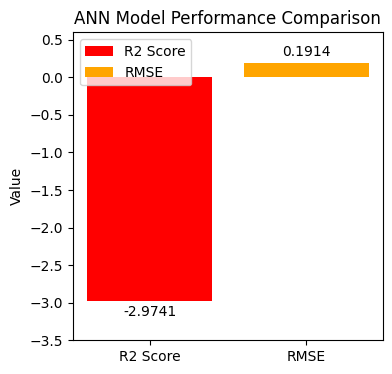

In [180]:
plt.figure(figsize=(4,4))

metrics = ["R2 Score", "RMSE"]
values = [ann_test_r2, ann_test_rmse]
colors = ['red', 'orange']

bars = plt.bar(metrics, values, color=colors)

# Add labels correctly
bars[0].set_label("R2 Score")
bars[1].set_label("RMSE")

# Value labels
for i, v in enumerate(values):
    if v < 0:
        plt.text(i, v - 0.2, str(round(v,4)), ha='center')
    else:
        plt.text(i, v + 0.1, str(round(v,4)), ha='center')

# Proper legend
plt.legend(loc='upper left')

# Better Y-axis
plt.ylim(-3.5, 0.6)

plt.title("ANN Model Performance Comparison")
plt.ylabel("Value")

plt.grid(False)
plt.show()

In [181]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting", "ANN"],
    "R2 Score": [
        lr_test_r2,
        rf_test_r2,
        gb_test_r2,
        ann_test_r2
    ],
    "RMSE": [
        lr_test_rmse,
        rf_test_rmse,
        gb_test_rmse,
        ann_test_rmse
    ]
})

print(results)

               Model  R2 Score      RMSE
0  Linear Regression  0.959322  0.020741
1      Random Forest  0.999133  0.002827
2  Gradient Boosting  0.998590  0.003606
3                ANN -2.974111  0.191427


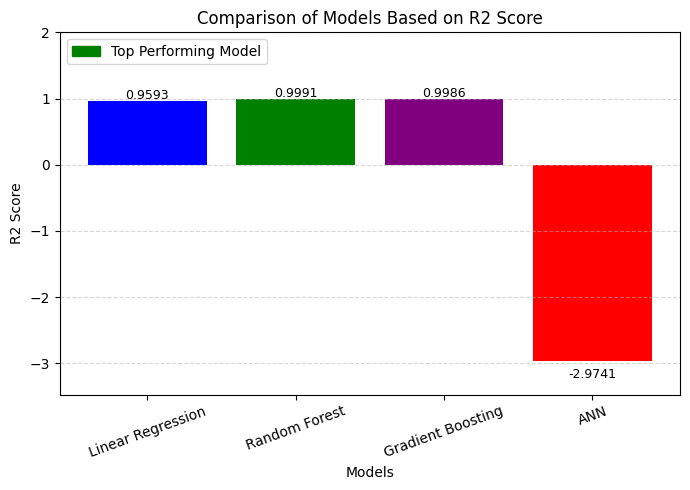

In [182]:
plt.figure(figsize=(7,5))
models = results["Model"]
r2_scores = results["R2 Score"]
colors = ['blue', 'green', 'purple', 'red']
bars = plt.bar(models, r2_scores, color=colors)
for i, v in enumerate(r2_scores):
    if v >= 0:
        plt.text(i, v + 0.03, f"{v:.4f}", ha='center', fontsize=9)
    else:
        plt.text(i, v - 0.25, f"{v:.4f}", ha='center', fontsize=9)
best_idx = np.argmax(r2_scores)
plt.xticks(rotation=20)
plt.ylim(min(r2_scores)-0.5, 2)
green_patch = mpatches.Patch(color='green', label='Top Performing Model')
plt.legend(handles=[green_patch], loc='upper left')
plt.title("Comparison of Models Based on R2 Score")
plt.ylabel("R2 Score")
plt.xlabel("Models")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

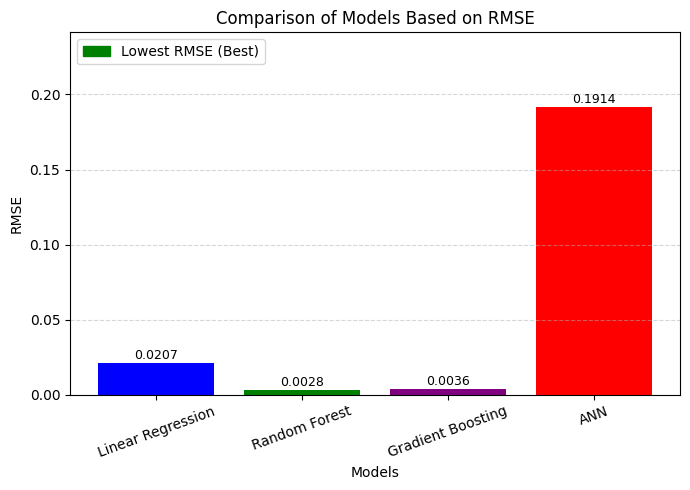

In [186]:
plt.figure(figsize=(7,5),dpi=100)
models = results["Model"]
rmse_vals = results["RMSE"]
colors = ['blue', 'green', 'purple', 'red']
bars = plt.bar(models, rmse_vals, color=colors)
for i, v in enumerate(rmse_vals):
    plt.text(i, v + 0.003, f"{v:.4f}", ha='center', fontsize=9)
best_idx = np.argmin(rmse_vals)
plt.xticks(rotation=20)
plt.ylim(0, max(rmse_vals) + 0.05)
legend_patch = mpatches.Patch(color='green', label='Lowest RMSE (Best)')
plt.legend(handles=[legend_patch], loc='upper left')
plt.title("Comparison of Models Based on RMSE")
plt.ylabel("RMSE")
plt.xlabel("Models")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()